# README File
This code trains two CNN architectures on the intel image classification dataset to classify images into 6 labels.

Required Libraries:
* os
* cv2
* numpy as np
* kagglehub
* tensorflow as tf
* from tensorflow import keras
* from sklearn.preprocessing import LabelBinarizer
* from tensorflow.keras.optimizers import SGD
* pandas as pd
* from sklearn.metrics import accuracy_score, precision_score
* matplotlib.pyplot as plt

Important note: Use a high resource TPU (I used L4) as there are 16 combinations of architectures, optimizers, batch sizes, and learning rates.



In [ ]:
## importing libraries
import os
import cv2
import numpy as np
import kagglehub
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.optimizers import SGD
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
import matplotlib.pyplot as plt

In [ ]:
# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


Using os to create labels via file path.

**Batch size: 32**

In [ ]:

train_path = os.path.join(path, 'seg_train', 'seg_train')
test_path = os.path.join(path, 'seg_test', 'seg_test')

# Create training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='categorical',  # for multi-class classification
    image_size=(150, 150),     # optional if all images are already 150x150
    batch_size=32,
    shuffle=True
)

# Create test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(150, 150),     # optional
    batch_size=32,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


**Model 1:** Implement one CNN model with 3 Conv layer and three and 3 max_pooling layers. Add a
dropout layer and a dense layer before the output layer

In [ ]:
## Building the first CNN architecture
base_cnn_model = tf.keras.models.Sequential()
base_cnn_model.add(tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
base_cnn_model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
base_cnn_model.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
base_cnn_model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
base_cnn_model.add(tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
base_cnn_model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
base_cnn_model.add(tf.keras.layers.Flatten())
base_cnn_model.add(tf.keras.layers.Dense(128, activation='relu'))
base_cnn_model.add(tf.keras.layers.Dropout(0.5))
base_cnn_model.add(tf.keras.layers.Dense(6, activation='softmax'))


## Building the second CNN architecture
base_cnn_model_2 = tf.keras.models.Sequential()
base_cnn_model_2.add(tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
base_cnn_model_2.add(tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
base_cnn_model_2.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
base_cnn_model_2.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
base_cnn_model_2.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
base_cnn_model_2.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
base_cnn_model_2.add(tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
base_cnn_model_2.add(tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
base_cnn_model_2.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
base_cnn_model_2.add(tf.keras.layers.Flatten())
base_cnn_model_2.add(tf.keras.layers.Dense(128, activation='relu'))
base_cnn_model_2.add(tf.keras.layers.Dropout(0.5))
base_cnn_model_2.add(tf.keras.layers.Dense(6, activation='softmax'))


In [ ]:
cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-3), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-3), metrics=['accuracy'])
cnn_model_2.summary()


history_cnn1_btch32_adam1e3 = cnn_model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)

history_cnn2_btch32_adam1e3 = cnn_model_2.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)

cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-4), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-4), metrics=['accuracy'])
cnn_model_2.summary()

history_cnn1_btch32_adam1e4 = cnn_model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)

history_cnn2_btch32_adam1e4 = cnn_model_2.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,694 (10.22 MB)

 Trainable params: 2,678,694 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,727,190 (10.40 MB)

 Trainable params: 2,727,190 (10.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.2013 - loss: 5.4336 - val_accuracy: 0.1760 - val_loss: 1.7916
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1846 - loss: 1.7907 - val_accuracy: 0.1780 - val_loss: 1.7896
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1961 - loss: 1.7888 - val_accuracy: 0.1753 - val_loss: 1.7908
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1822 - loss: 1.7928 - val_accuracy: 0.1753 - val_loss: 1.7907
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1830 - loss: 1.7906 - val_accuracy: 0.1753 - val_loss: 1.7906
Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.2383 - loss: 3.1755 - val_accuracy: 0.5247 - val_loss: 1.3004
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4276 - loss: 1.4153 - val_accuracy: 0.5800 - val_loss: 1.1080
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5272 - loss: 1.1966 - val_accuracy: 

In [ ]:
cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.001, momentum=0.9), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.001, momentum=0.9), metrics=['accuracy'])
cnn_model_2.summary()


history_cnn1_btch32_SGD1e3 = cnn_model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)

history_cnn2_btch32_SGD1e3 = cnn_model_2.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)

cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.01, momentum=0.9), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.01, momentum=0.9), metrics=['accuracy'])
cnn_model_2.summary()


history_cnn1_btch32_SGD1e2 = cnn_model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)

history_cnn2_btch32_SGD1e2 = cnn_model_2.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs=5,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,694 (10.22 MB)

 Trainable params: 2,678,694 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,727,190 (10.40 MB)

 Trainable params: 2,727,190 (10.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1694 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1702 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1705 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1689 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1691 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.1705 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1704 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1694 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 4/5
439/439 ━━━━━━━━

**Batch size: 16**

In [ ]:
train_path = os.path.join(path, 'seg_train', 'seg_train')
test_path = os.path.join(path, 'seg_test', 'seg_test')

# Create training dataset
train_dataset_16 = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='categorical',  # for multi-class classification
    image_size=(150, 150),     # optional if all images are already 150x150
    batch_size=16,
    shuffle=True
)

# Create test dataset
test_dataset_16 = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='categorical',
    image_size=(150, 150),     # optional
    batch_size=16,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [ ]:
cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-3), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-3), metrics=['accuracy'])
cnn_model_2.summary()


history_cnn1_btch16_adam1e3 = cnn_model.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

history_cnn2_btch16_adam1e3 = cnn_model_2.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-4), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-4), metrics=['accuracy'])
cnn_model_2.summary()

history_cnn1_btch16_adam1e4 = cnn_model.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

history_cnn2_btch16_adam1e4 = cnn_model_2.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,694 (10.22 MB)

 Trainable params: 2,678,694 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,727,190 (10.40 MB)

 Trainable params: 2,727,190 (10.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1660 - loss: 9.6776 - val_accuracy: 0.1757 - val_loss: 1.7910
Epoch 2/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1811 - loss: 1.7912 - val_accuracy: 0.1757 - val_loss: 1.7909
Epoch 3/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1817 - loss: 1.7923 - val_accuracy: 0.1757 - val_loss: 1.7906
Epoch 4/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1811 - loss: 1.7908 - val_accuracy: 0.1757 - val_loss: 1.7905
Epoch 5/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1807 - loss: 1.7907 - val_accuracy: 0.1757 - val_loss: 1.7903
Epoch 1/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.3075 - loss: 3.5086 - val_accuracy: 0.4840 - val_loss: 1.3610
Epoch 2/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4245 - loss: 1.4434 - val_accuracy: 0.5507 - val_loss: 1.2129
Epoch 3/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5023 - loss: 1.2638 - val_accuracy: 0.6837 

In [ ]:
cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.001, momentum=0.9), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.001, momentum=0.9), metrics=['accuracy'])
cnn_model_2.summary()


history_cnn1_btch16_SGD1e3 = cnn_model.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

history_cnn2_btch16_SGD1e3 = cnn_model_2.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

cnn_model = tf.keras.models.clone_model(base_cnn_model)
cnn_model.build(input_shape=(None,150,150,3))
cnn_model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.01, momentum=0.9), metrics=['accuracy'])
cnn_model.summary()

cnn_model_2 = tf.keras.models.clone_model(base_cnn_model_2)
cnn_model_2.build(input_shape=(None,150,150,3))
cnn_model_2.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.01, momentum=0.9), metrics=['accuracy'])
cnn_model_2.summary()


history_cnn1_btch16_SGD1e2 = cnn_model.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

history_cnn2_btch16_SGD1e2 = cnn_model_2.fit(
    train_dataset_16,
    validation_data = test_dataset_16,
    epochs=5,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,694 (10.22 MB)

 Trainable params: 2,678,694 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,727,190 (10.40 MB)

 Trainable params: 2,727,190 (10.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.1673 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 2/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1653 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 3/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1665 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 4/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1666 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 5/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1675 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 1/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.1672 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 2/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.1657 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 3/5
878/878 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.1662 - loss: nan - val_accuracy: 0.1670 - val_loss: nan
Epoch 4/5
878/878 ━━━━━━━━━━━

# Reporting Results

In [ ]:
models = [
    ("CNN1, batch = 32, Adam, 1e-3", history_cnn1_btch32_adam1e3.model),
    ("CNN2, batch = 32, Adam, 1e-3", history_cnn2_btch32_adam1e3.model),
    ("CNN1, batch = 32, Adam, 1e-4", history_cnn1_btch32_adam1e4.model),
    ("CNN2, batch = 32, Adam, 1e-4", history_cnn2_btch32_adam1e4.model),
    ("CNN1, batch = 32, SGD, 1e-3", history_cnn1_btch32_SGD1e3.model),
    ("CNN2, batch = 32, SGD, 1e-3", history_cnn2_btch32_SGD1e3.model),
    ("CNN1, batch = 32, SGD, 1e-2", history_cnn1_btch32_SGD1e2.model),
    ("CNN2, batch = 32, SGD, 1e-2", history_cnn2_btch32_SGD1e2.model),
    ("CNN1, batch = 16, Adam, 1e-3", history_cnn1_btch16_adam1e3.model),
    ("CNN2, batch = 16, Adam, 1e-3", history_cnn2_btch16_adam1e3.model),
    ("CNN1, batch = 16, Adam, 1e-4", history_cnn1_btch16_adam1e4.model),
    ("CNN2, batch = 16, Adam, 1e-4", history_cnn2_btch16_adam1e4.model),
    ("CNN1, batch = 16, SGD, 1e-3", history_cnn1_btch16_SGD1e3.model),
    ("CNN2, batch = 16, SGD, 1e-3", history_cnn2_btch16_SGD1e3.model),
    ("CNN1, batch = 16, SGD, 1e-2", history_cnn1_btch16_SGD1e2.model),
    ("CNN2, batch = 16, SGD, 1e-2", history_cnn2_btch16_SGD1e2.model)
]

## finding the true labels
y_true_list = []
for batch in test_dataset:
    y_batch = batch[1]
    for y in y_batch:
        y_true_list.append(y.numpy())

y_true = np.array(y_true_list)
y_true_labels = np.argmax(y_true, axis=1)


## storing the resuls
results_holder = []
for name, model in models:

    predictions = model.predict(test_dataset)
    y_pred_labels = np.argmax(predictions, axis=1)

    total_accuracy = accuracy_score(y_true_labels, y_pred_labels)
    per_class_accuracy = precision_score(y_true_labels, y_pred_labels, average=None)

    result = {"Model": name, "Total Accuracy": total_accuracy}

    i = 0 ## AI usage here, i didn't know how to do per class acc.
    for cls_name in test_dataset.class_names:
      result[cls_name + "_acc"] = per_class_accuracy[i]
      i = i + 1

    results_holder.append(result)

final_results = pd.DataFrame(results_holder)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
37/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
39/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
40/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(final_results)

                           Model  Total Accuracy  buildings_acc  forest_acc  \
0   CNN1, batch = 32, Adam, 1e-3        0.744333       0.697987    0.867589   
1   CNN2, batch = 32, Adam, 1e-3        0.747000       0.891892    0.899384   
2   CNN1, batch = 32, Adam, 1e-4        0.175333       0.000000    0.000000   
3   CNN2, batch = 32, Adam, 1e-4        0.738667       0.742857    0.905830   
4    CNN1, batch = 32, SGD, 1e-3        0.617333       0.682065    0.985075   
5    CNN2, batch = 32, SGD, 1e-3        0.721333       0.738426    0.936916   
6    CNN1, batch = 32, SGD, 1e-2        0.145667       0.145667    0.000000   
7    CNN2, batch = 32, SGD, 1e-2        0.145667       0.145667    0.000000   
8   CNN1, batch = 16, Adam, 1e-3        0.676000       0.754144    0.847953   
9   CNN2, batch = 16, Adam, 1e-3        0.802000       0.834586    0.959574   
10  CNN1, batch = 16, Adam, 1e-4        0.175667       0.000000    1.000000   
11  CNN2, batch = 16, Adam, 1e-4        0.759000    

# Results Discussion

I ran 16 test cases for analyzing impacts of model architecture, optimizer type, learning rate, and batch size. I tested two models (3 layer and 6 layer CNN), two batch sizes (batch_size = 32 and batch_size = 16), two optimization types (Adam and SGD), and two learning rates per optimizer (0.0001 and 0.001 for Adam, 0.001 and 0.01 for SGD).

The top performing model on total accuracy was the 6 layer CNN that used a batch size of 16, the adam optimizer, and a learning rate of 0.001. On top of the great performance of it's total accuracy (80.20%), it performed well on all of the per-class accuracies ranging between 68-96%. Overall trends showed that a learning rate of 0.0001 for adam optimization was a bit too low for the 3 layer CNN architecture, but was more suffient with the 6 layer model. Performance was more in line between the three and six layer architectures when the learning rate was higher at 0.001 when adam optimization was used. Additionally, the 0.001 learning rate for SGD was too high for both architectures, while 0.01 was a better balance for this application overall.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


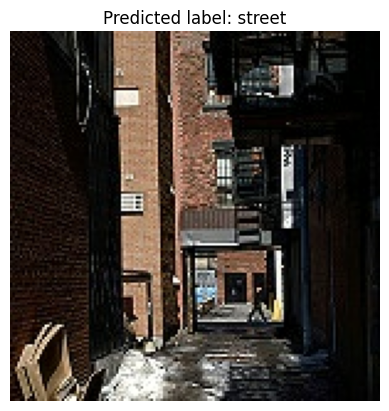

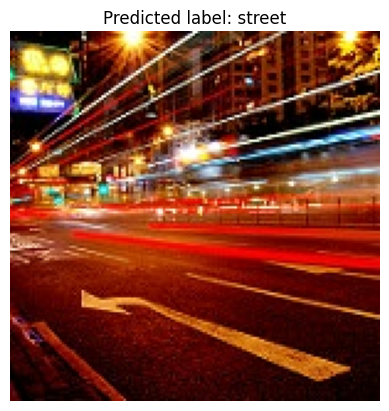

In [ ]:
for images, labels in test_dataset.take(123):
    sample_images = images[:2]
    sample_labels = labels[:2]

## used my best model
predict_image = history_cnn2_btch16_adam1e3.model.predict(sample_images)
pred_labels = np.argmax(predict_image, axis=1)

plt.imshow(sample_images[0].numpy().astype("uint8")) ## had to ask chat gpt here
plt.title(f"Predicted label: {test_dataset.class_names[pred_labels[0]]}")
plt.axis('off')
plt.show()

plt.imshow(sample_images[1].numpy().astype("uint8")) ## had to ask chat gpt here
plt.title(f"Predicted label: {test_dataset.class_names[pred_labels[1]]}")
plt.axis('off')
plt.show()